In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.stats import ks_2samp
from pathlib import Path
import os

cwd = Path.cwd()
parent = cwd.parent

### Check 2nd Order Perturbation Contributions to Low-Variance Eigenvalues 

It's the expected change in one eigenvalue, when adding a new sample to the dataset.

\begin{equation}
    \langle \lambda_\alpha^{(2)} \rangle = \frac{1}{(M+1)^2}\lambda_\alpha \sum_{\beta \ne \alpha} \frac{\lambda_\beta}{\lambda_\alpha-\lambda_\beta}
\end{equation}

We will define the relative perturbation as 

\begin{equation}
    \epsilon_\alpha = \frac{|\langle \lambda_\alpha^{(2)} \rangle |}{\lambda_\alpha}
\end{equation}

which is what we really care about (actually maybe not so much).

What we really care about is whether the typical perturbation of an eigenvalue is larger or smaller than the typical distance between any two consecutive eigenvalues. If it's smaller, then the eigenmodes can be considered as unmixed. If it is bigger, then a perturbation can easily make two eigenmodes cross and so we can consider the eigenmodes as mixed.


So we care about 

\begin{equation}
    |\langle \lambda_\alpha^{(2)} \rangle | / d_\alpha
\end{equation}

where $d_\alpha$ is the minimum distance between $\lambda_\alpha$ and one of its neighbors.



In [2]:
dataset_names = ['Glacier','GUT.SRP056641','GUT.ERP015450','Lake','Oral','River','Soil','activatedsludge']
dataset_names = ['Estrella_full']+['Grilli.'+name for name in dataset_names]

dataset_labels = ['Estrela','Glacier','Gut1','Gut2','Lake','Oral','River','Soil','Sludge']

dataset_names = ['Goldford.Glucose','Goldford.Citrate']+dataset_names
dataset_labels = ['Glucose','Citrate']+dataset_labels

In [4]:
epsilon_low_data = []
epsilon_high_data = []
distances_low_data  = []
distances_high_data = []


for dataset in dataset_names:
    with open('../../out/{}/low_variance_eigvals.{}.dat'.format(dataset,dataset),
              'rb') as f:
        lowvar_eigvals = pickle.load(f) #(N_species,N_vectors)
        N_low = len(lowvar_eigvals)
        f.close()
    with open('../../out/{}/high_variance_eigvals.{}.dat'.format(dataset,dataset),
              'rb') as f:
        highvar_eigvals = pickle.load(f)
        N_high = len(highvar_eigvals)
        f.close()

    with open('../../out/{}/eigvals.{}.dat'.format(dataset,dataset),
              'rb') as f:
        eigvals = pickle.load(f)
        N_total = len(eigvals)
        f.close()

    with open('../../out/{}/full_dataset.filtered.{}.dat'.format(dataset,dataset),
              'rb') as f:
        full_dataset = pickle.load(f)
        M,N = np.shape(full_dataset)
        f.close()

    if M<N:
        eigvals = eigvals[-(M-1):]
    order2_perturbations = []
    distances = []
    for alpha,lam in enumerate(eigvals):
        other_eigvals = np.delete(eigvals,alpha)
        perturbation = 1/(M+1)**2*lam*np.sum(other_eigvals/(lam-other_eigvals))
        abs_perturbation = np.abs(perturbation)
        order2_perturbations.append(abs_perturbation)

        if alpha==0:
            dist = eigvals[alpha+1]-eigvals[alpha]
        elif alpha == len(eigvals)-1:
            dist = eigvals[alpha]-eigvals[alpha-1]
        else:
            dist = min(eigvals[alpha+1]-eigvals[alpha], eigvals[alpha]-eigvals[alpha-1])

        distances.append(dist)

    order2_perturbations = np.array(order2_perturbations)
    
    lowvar_perturbations = order2_perturbations[:N_low]
    highvar_perturbations = order2_perturbations[-N_high:]
    noise_perturbations = order2_perturbations[N_low:N_total-N_high]
    
    distances = np.array(distances)
    lowvar_distances = distances[:N_low]
    highvar_distances = distances[-N_high:]
    noise_distances = distances[N_low:N_total-N_high]

    ''' If considering abs. perturbation vs min distance with a neighbor '''
    epsilon_low_data.append(lowvar_perturbations/lowvar_distances)
    epsilon_high_data.append(highvar_perturbations/highvar_distances)
    
        
    

0.9333333333333332
0.8095238095238095
0.4000000000000001
0.008771929824561403
0.0057595529731752654
1.1875187826555247e-10
5.451375573755195e-10
0.0002002359464158
7.368446585068829e-12
1.4991623584735753e-10
3.370581848482149e-39


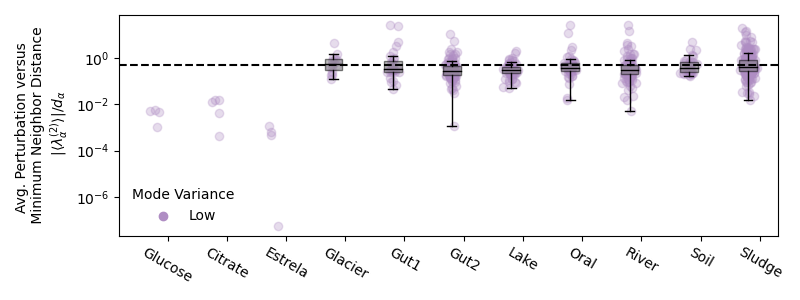

In [6]:
%matplotlib widget
fig,ax = plt.subplots(figsize=(8,3))
for i,dataset in enumerate(dataset_names):
    lo_dat = epsilon_low_data[i]
    hi_dat = epsilon_high_data[i]
    N_lo = len(lo_dat)
    N_hi = len(hi_dat)

    KS_result = ks_2samp(lo_dat,hi_dat,
                         alternative='two-sided')
    print(KS_result.pvalue)
    ''' Plot Boxplots '''
    if i>2: #aka not the estrela dataset
        bplot = ax.boxplot(list(lo_dat),
            positions=[i+0.1],
            patch_artist=True, medianprops=dict(color='k'),showfliers=False,
                           widths=0.3
            )
        bplot['boxes'][0].set_facecolor('tab:gray')
        bplot['boxes'][0].set_alpha(0.5)
    ax.scatter(np.random.normal(i+0.1,0.05,size=len(lo_dat)),lo_dat,
              # edgecolor='k',
               color=[175/255,141/255,195/255],alpha=0.3,
              zorder=0,
              label=None)
    ax.scatter(None,None,
              # edgecolor='k',
               color=[175/255,141/255,195/255],alpha=1,
              zorder=0,
              label='Low' if i==0 else None)
        

ax.set_ylabel(r'Avg. Rel. Perturbation $|\langle \lambda_\alpha^{(2)} \rangle |/\lambda_\alpha$')
ax.set_ylabel(r'Avg. Abs. Perturbation $|\langle \lambda_\alpha^{(2)} \rangle |$')
ax.set_ylabel('Avg. Perturbation versus \n Minimum Neighbor Distance \n'+r' $|\langle \lambda_\alpha^{(2)} \rangle |/d_\alpha$')
ax.set_xticks(np.arange(len(dataset_names))+0.3)
ax.set_xticklabels(dataset_labels,rotation=-30,ha='center')
ax.legend(loc='best',frameon=False,
          title='Mode Variance')
ax.axhline(y=5e-1,color='k',linestyle='--') #half the minimum distance to its nearest neighbor
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('order2_eigenvalue_perturbations.svg',
           format='svg',transparent=True)
plt.savefig('order2_eigenvalue_perturbations.png',
           format='png',transparent=True)
